In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import sys

sys.path.append("..")
from src.trees.boosting.gradient_boosting import FastBinaryGradientBoosting

In [2]:
# =====================================================================
# 2. RUNNING THE SANITY TEST IN THE NOTEBOOK
# =====================================================================

print("Generating synthetic 2D Moon classification data...")
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Instantiate our custom optimized model
gbm = FastBinaryGradientBoosting(
    n_estimators=80,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,  # Row subsampling enabled
    max_features="sqrt",  # Feature subsampling enabled
    reg_lambda=1.5,  # L2 Regularization parameter
    random_state=42,
)

print("Fitting FastBinaryGradientBoosting...")
gbm.fit(X_train, y_train)

# Evaluate predictions
y_pred = gbm.predict(X_test)
y_probs = gbm.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print("\n--- Model Test Metrics ---")
print(f"Test Accuracy: {acc:.4f} (expected: ~0.90+)")
print(f"Test AUC-ROC:  {auc:.4f} (expected: ~0.96+)")

Generating synthetic 2D Moon classification data...
Fitting FastBinaryGradientBoosting...

--- Model Test Metrics ---
Test Accuracy: 0.9056 (expected: ~0.90+)
Test AUC-ROC:  0.9680 (expected: ~0.96+)


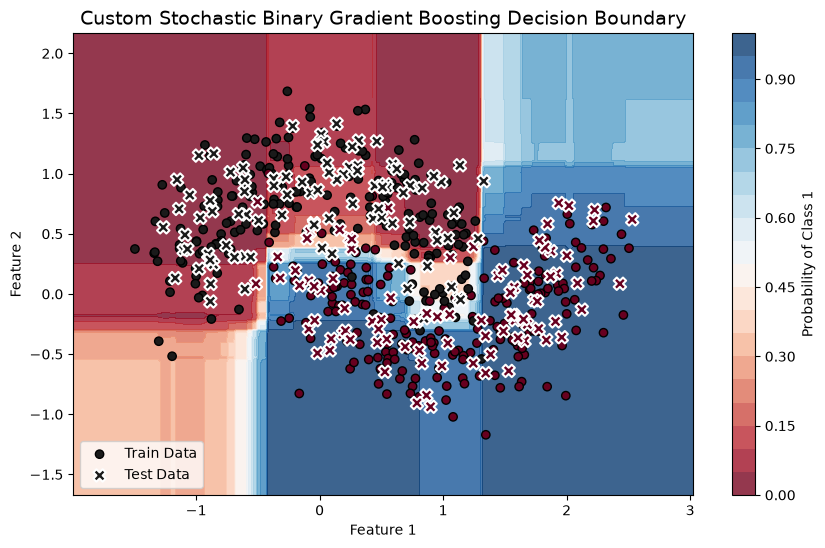

In [3]:
# =====================================================================
# 3. VISUALIZING DECISION BOUNDARIES
# =====================================================================

# Draw grid boundaries
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict probability across mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = gbm.predict_proba(grid_points)[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.8)
plt.colorbar(contour, label="Probability of Class 1")

# Scatter plot actual dataset labels
scatter_train = plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="RdGy_r",
    edgecolors="k",
    marker="o",
    label="Train Data",
)
scatter_test = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="RdGy_r",
    edgecolors="w",
    linewidths=1.5,
    marker="X",
    s=80,
    label="Test Data",
)

plt.title("Custom Stochastic Binary Gradient Boosting Decision Boundary", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="lower left")
plt.show()